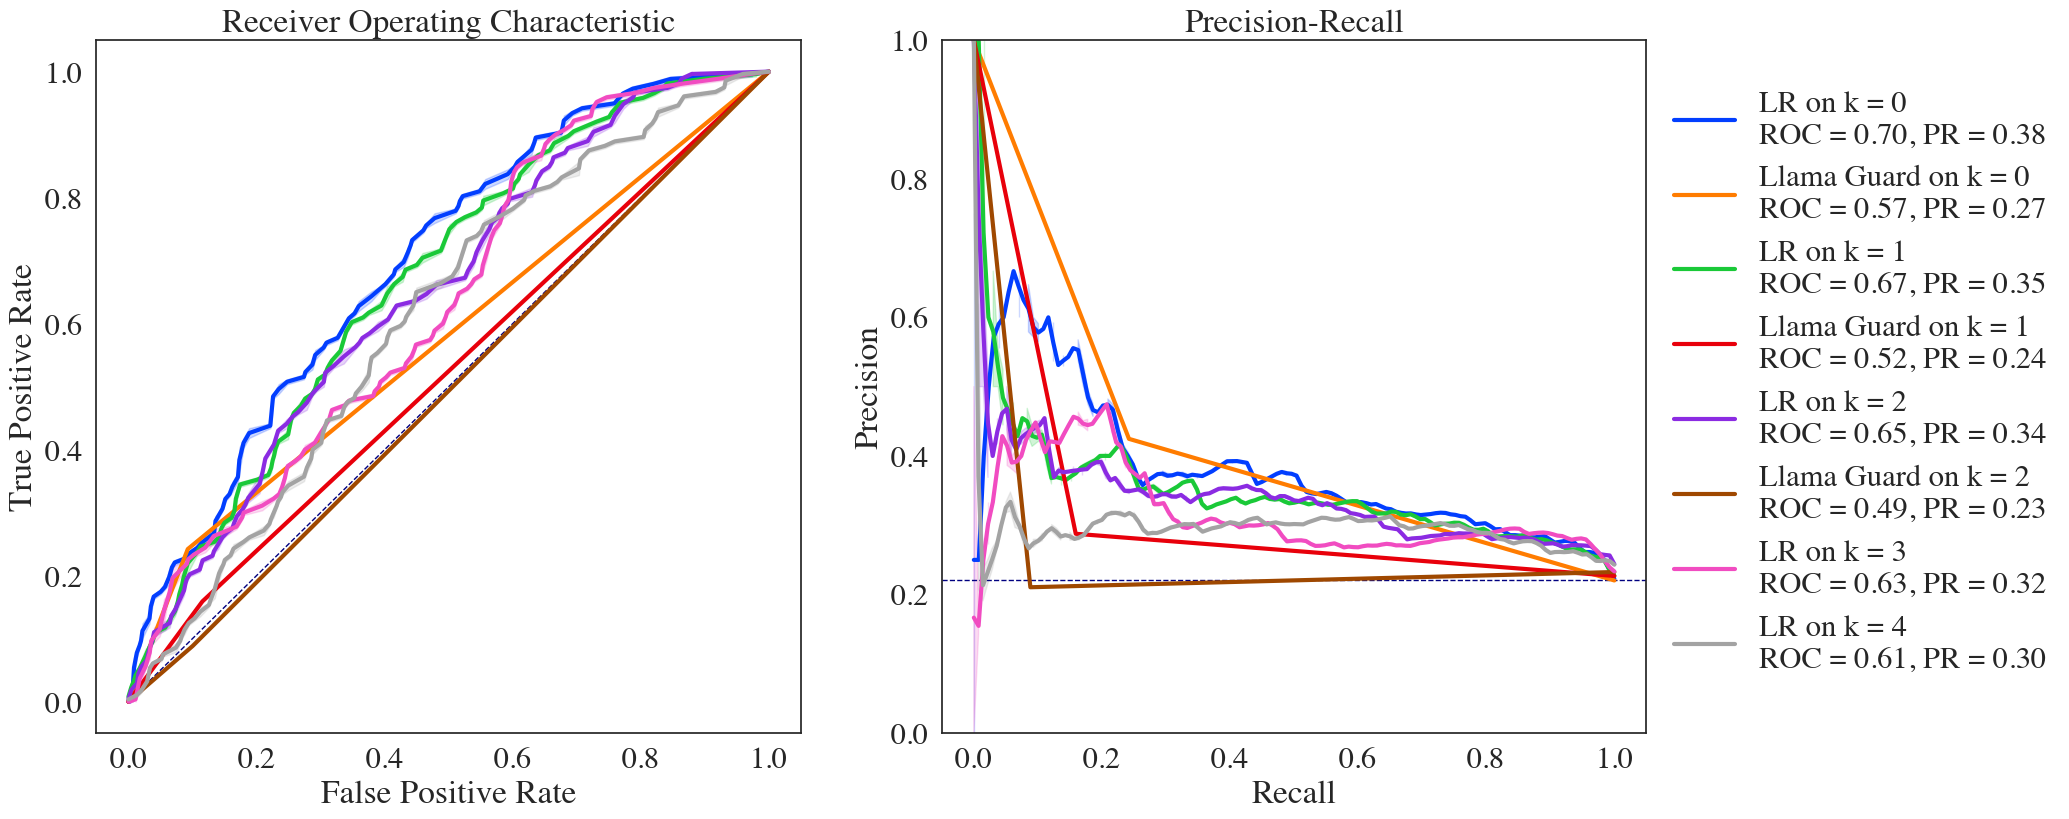

In [5]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score


root_dir = Path("/Users/muberraozmen/Development/psycho-pass")
experiment_root = root_dir / "experiments" / "analysis"
results_dirs = {
    # (0, "GB"): experiment_root / "experiment3a" /"predictions_gradient_boosting.csv",
    (0, "LR"): experiment_root / "experiment3a" / "predictions_logistic_regression.csv",
    (0, "Llama Guard"): experiment_root / "experiment3a" / "predictions_llama_guard.csv",
    # (1, "GB"): experiment_root / "experiment3b" /"predictions_gradient_boosting.csv",
    (1, "LR"): experiment_root / "experiment3b" / "predictions_logistic_regression.csv",
    (1, "Llama Guard"): experiment_root / "experiment3b" / "predictions_llama_guard.csv",
    # (2, "GB"): experiment_root / "experiment3c" /"predictions_gradient_boosting.csv",
    (2, "LR"): experiment_root / "experiment3c" / "predictions_logistic_regression.csv",
    (2, "Llama Guard"): experiment_root / "experiment3c" / "predictions_llama_guard.csv",
    # (3, "GB"): experiment_root / "experiment3d" /"predictions_gradient_boosting.csv",
    (3, "LR"): experiment_root / "experiment3d" / "predictions_logistic_regression.csv",
    # (3, "Llama Guard"): experiment_root / "experiment3d" / "predictions_llama_guard.csv",
    # (4, "GB"): experiment_root / "experiment3e" /"predictions_gradient_boosting.csv",
    (4, "LR"): experiment_root / "experiment3e" / "predictions_logistic_regression.csv",
    # (4, "Llama Guard"): experiment_root / "experiment3e" / "predictions_llama_guard.csv",
}

sns.set_theme(style="white", palette="bright", font='times', font_scale=2)
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Chance reference lines
sample = pd.read_csv(next(iter(results_dirs.values())))
pos_rate = sample["outcome"].mean()
axes[0].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
axes[1].axhline(y=pos_rate, color='navy', lw=1, linestyle='--')

for (trim, method), fname in results_dirs.items():
    predictions = pd.read_csv(fname)
    fpr, tpr, _ = roc_curve(predictions["outcome"], predictions["prediction"])
    roc_auc_val = auc(fpr, tpr)
    pre, rec, _ = precision_recall_curve(predictions["outcome"], predictions["prediction"])
    pr_auc_val = average_precision_score(predictions["outcome"], predictions["prediction"])
    label = f'{method} on k = {trim}\nROC = {roc_auc_val:.2f}, PR = {pr_auc_val:.2f}'
    sns.lineplot(x=fpr, y=tpr, ax=axes[0], label=label, linewidth=3)
    sns.lineplot(x=rec, y=pre, ax=axes[1], label=label, linewidth=3)

axes[0].set_title('Receiver Operating Characteristic')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[1].set_title('Precision-Recall')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_ylim([0, 1])

# Single shared legend on the right
handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(0.9, 0.5), frameon=False)

plt.savefig(root_dir/"paper"/"plots"/"exp3.pdf", bbox_inches='tight')
plt.show()
